# Sales Prediction (SVM Regression)

### Problem Statement

Build a model which predicts sales (thosands of units) based on the money spent (in thousands of dollers) on different platforms for marketing.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
advertising = pd.read_csv("/content/Advertising.csv",index_col=0)
advertising.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Data Inspection

In [5]:
advertising.shape

(200, 4)

In [6]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [7]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Data Cleaning

In [8]:
advertising.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


## Outlier Analysis

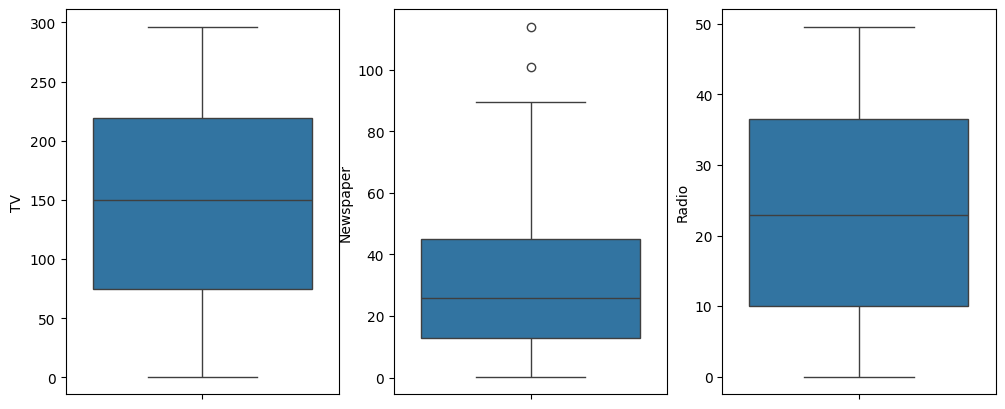

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt1 = sns.boxplot(advertising['TV'])

plt.subplot(1,3,2)
plt2 = sns.boxplot(advertising['Newspaper'])

plt.subplot(1,3,3)
plt3 = sns.boxplot(advertising['Radio'])

## Exploratory Data Analysis

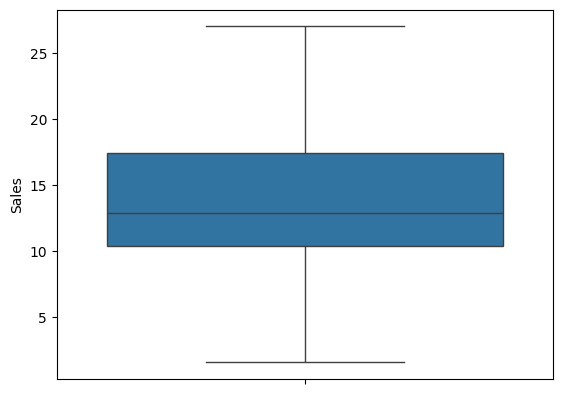

In [10]:
sns.boxplot(advertising['Sales'])
plt.show()

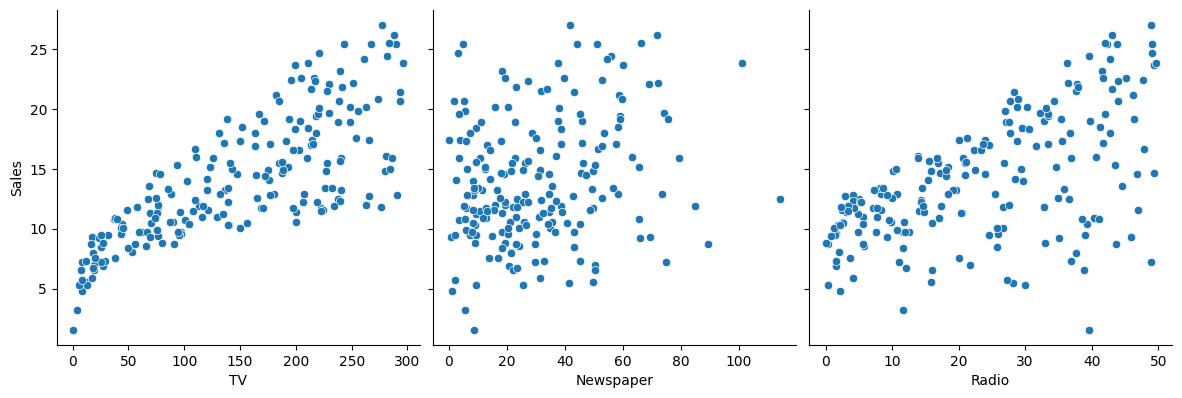

In [11]:
# Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(advertising, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

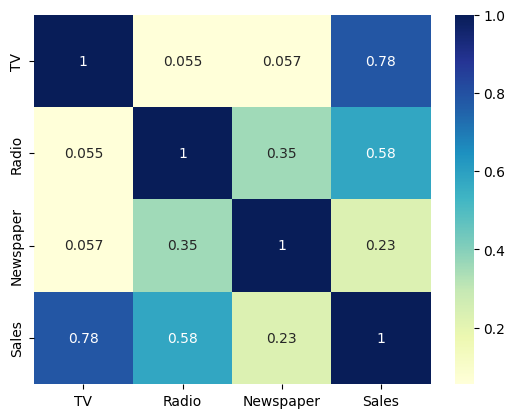

In [12]:
# Let's see the correlation between different variables.
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

## Model Building

In [13]:
X = advertising.drop('Sales',axis=1)
y = advertising['Sales']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.2, random_state = 42)

In [15]:
# Let's now take a look at the train dataset
X_train.head()

,TV,Radio,Newspaper
176,276.9,48.9,41.8
135,36.9,38.6,65.6
168,206.8,5.2,19.4
184,287.6,43.0,71.8
64,102.7,29.6,8.4


In [16]:
y_train.head()

,Sales
176,27.0
135,10.8
168,12.2
184,26.2
64,14.0


In [ ]:
from sklearn.preprocessing import StandardScaler
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled[:5]

array([[ 1.51009195,  1.72058739,  0.46701186],
       [-1.38575167,  1.03541244,  1.7261319 ],
       [ 0.6642643 , -1.18641702, -0.7180423 ],
       [ 1.63919832,  1.32810853,  2.05413796],
       [-0.59180788,  0.43671588, -1.29998854]])

In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100, epsilon=100 )
svr.fit(X_train_scaled, y_train)

SVR(C=100, epsilon=100)

In [ ]:
# Predict on the test set
y_pred = svr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 26.959624999999996


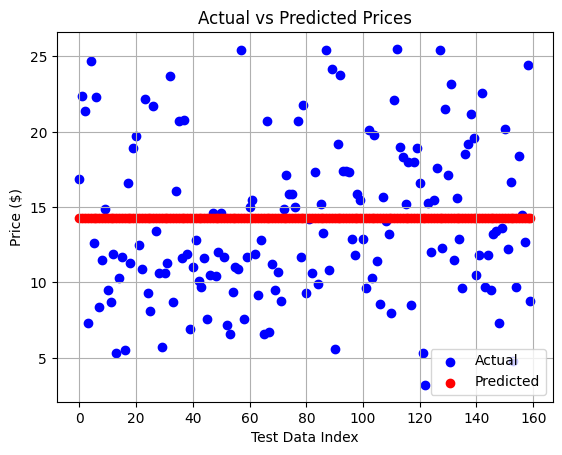

In [ ]:
# Visualize actual vs predicted values
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Test Data Index')
plt.ylabel('Price ($)')
plt.legend()
plt.grid()
plt.show()

## Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 100, 1000],
    'epsilon': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [ ]:
grid_search = GridSearchCV(SVR(),
                           param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           verbose=1)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000], 'epsilon': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
# Predict on the test set
y_pred = best_model.predict(X_test_scaled)

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 3.056378620931166


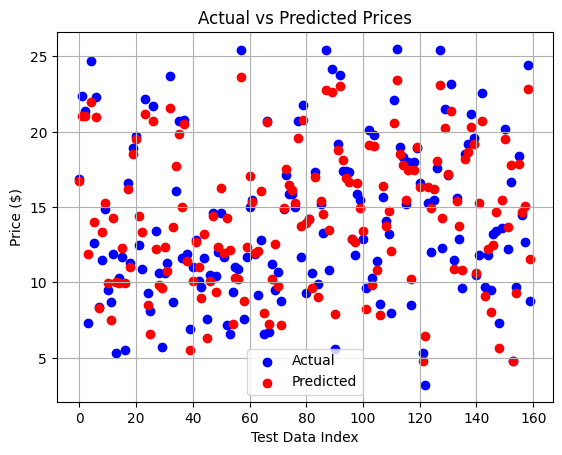

In [ ]:
# Visualize actual vs predicted values
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted')

plt.title('Actual vs Predicted Prices')
plt.xlabel('Test Data Index')
plt.ylabel('Price ($)')
plt.legend()
plt.grid()
plt.show()

## Visual Interpretation of SVR

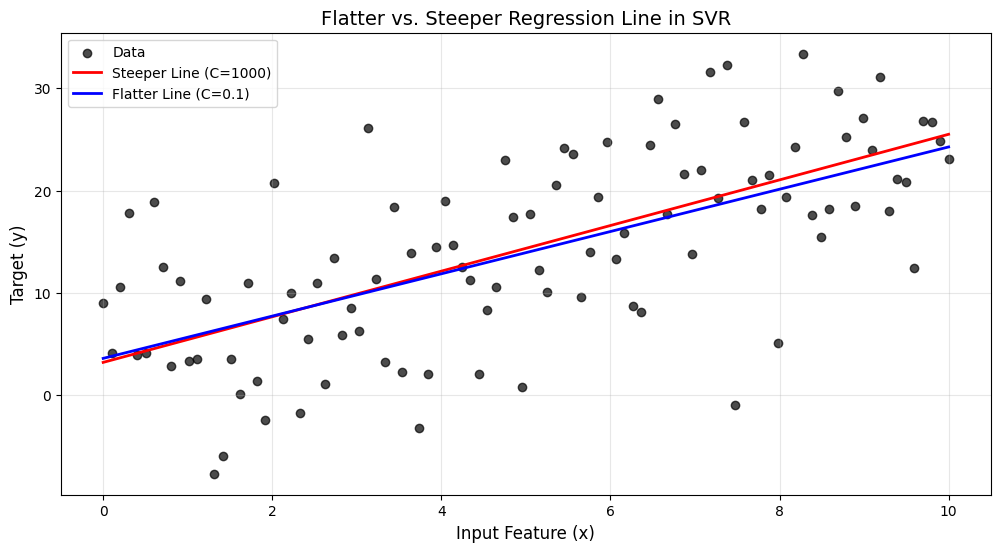

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Generate synthetic dataset
np.random.seed(42)
x = np.linspace(0, 10, 100).reshape(-1, 1)  # Input feature (2D array)
y = 2 * x.flatten() + 5 + np.random.normal(0, 8, size=x.shape[0])  # True function with more noise (1D array)

# Fit SVR models with different C values (affecting w and flatness)
# Steeper regression line (overfitting)
svr_steep = SVR(C=1000, epsilon=0.5, kernel='linear')
svr_steep.fit(x, y)

# Flatter regression line (better generalization)
svr_flat = SVR(C=0.1, epsilon=0.5, kernel='linear')
svr_flat.fit(x, y)

# Generate predictions for plotting
x_range = np.linspace(0, 10, 1000).reshape(-1, 1)
y_pred_steep = svr_steep.predict(x_range)
y_pred_flat = svr_flat.predict(x_range)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot data points
plt.scatter(x, y, color='black', label="Data", alpha=0.7)

# Plot steeper regression line
plt.plot(x_range, y_pred_steep, color='red', label="Steeper Line (C=1000)", linewidth=2)

# Plot flatter regression line
plt.plot(x_range, y_pred_flat, color='blue', label="Flatter Line (C=0.1)", linewidth=2)

# Formatting the plot
plt.title("Flatter vs. Steeper Regression Line in SVR", fontsize=14)
plt.xlabel("Input Feature (x)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


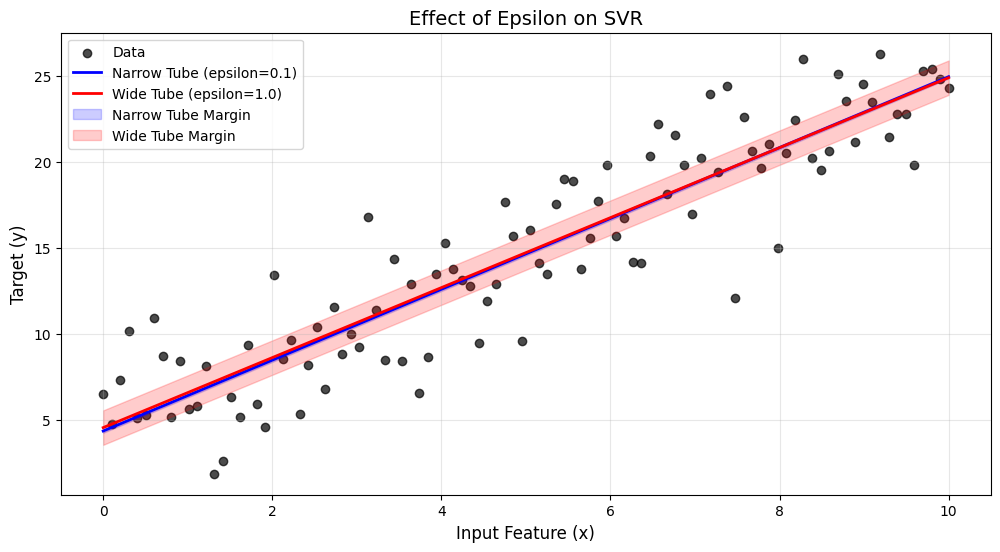

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Generate synthetic dataset
np.random.seed(42)
x = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * x.flatten() + 5 + np.random.normal(0, 3, size=x.shape[0])  # True function with noise

# SVR with different epsilon values
svr_small_epsilon = SVR(C=1, epsilon=0.1, kernel='linear')  # Narrow epsilon-tube
svr_small_epsilon.fit(x, y)

svr_large_epsilon = SVR(C=1, epsilon=1.0, kernel='linear')  # Wide epsilon-tube
svr_large_epsilon.fit(x, y)

# Generate predictions
x_range = np.linspace(0, 10, 1000).reshape(-1, 1)
y_pred_small = svr_small_epsilon.predict(x_range)
y_pred_large = svr_large_epsilon.predict(x_range)

# Plot data and regression lines
plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='black', label="Data", alpha=0.7)

# Plot regression lines
plt.plot(x_range, y_pred_small, color='blue', label="Narrow Tube (epsilon=0.1)", linewidth=2)
plt.plot(x_range, y_pred_large, color='red', label="Wide Tube (epsilon=1.0)", linewidth=2)

# Plot epsilon-tubes
plt.fill_between(
    x_range.flatten(),
    y_pred_small - 0.1,
    y_pred_small + 0.1,
    color='blue',
    alpha=0.2,
    label="Narrow Tube Margin",
)
plt.fill_between(
    x_range.flatten(),
    y_pred_large - 1.0,
    y_pred_large + 1.0,
    color='red',
    alpha=0.2,
    label="Wide Tube Margin",
)

# Formatting the plot
plt.title("Effect of Epsilon on SVR", fontsize=14)
plt.xlabel("Input Feature (x)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


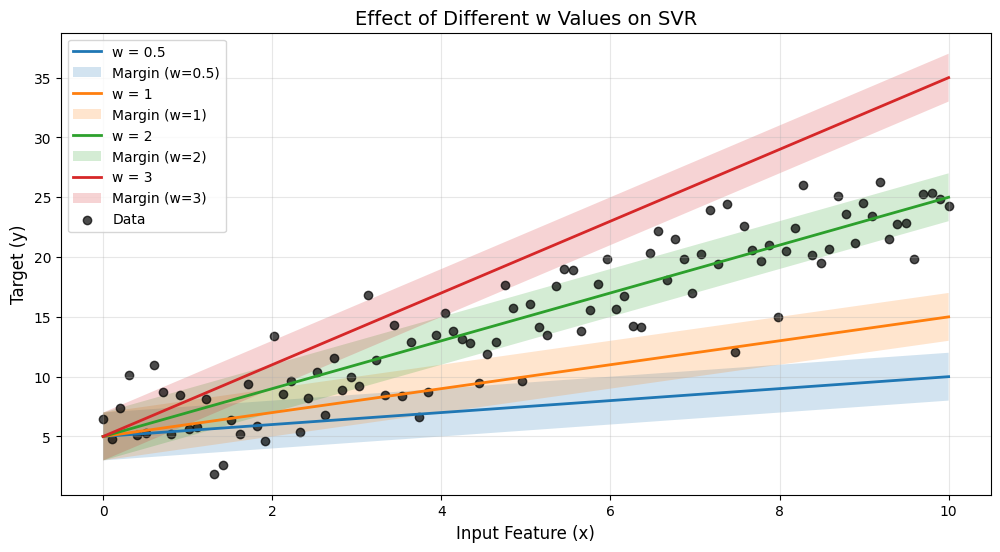

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic dataset
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + 5 + np.random.normal(0, 3, size=x.shape)  # True function with noise

# Define different weights (w values) to simulate different steepness
w_values = [0.5, 1, 2, 3]  # Small, moderate, and large w values
b = 5  # Intercept
epsilon = 2  # Margin for SVR

# Create regression lines and margins for different w values
plt.figure(figsize=(12, 6))
for w in w_values:
    y_pred = w * x + b  # Regression line
    upper_margin = y_pred + epsilon  # Upper epsilon margin
    lower_margin = y_pred - epsilon  # Lower epsilon margin

    # Plot regression line and margins
    plt.plot(x, y_pred, label=f"w = {w}", linewidth=2)
    plt.fill_between(x, lower_margin, upper_margin, alpha=0.2, label=f"Margin (w={w})")

# Plot the data points
plt.scatter(x, y, color="black", label="Data", alpha=0.7)

# Formatting the plot
plt.title("Effect of Different w Values on SVR", fontsize=14)
plt.xlabel("Input Feature (x)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()
